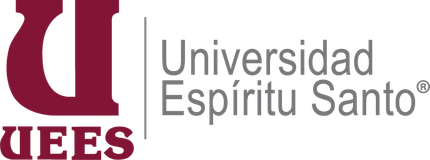

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 4 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E4.2 · Auditoría de sesgo y mitigación</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Medir la equidad de un clasificador con métricas desagregadas por grupo, entender por qué no se pueden cumplir todas a la vez, mitigar con Fairlearn y documentar el compromiso entre desempeño y equidad en un registro de riesgos. |
| **Resultado de aprendizaje** | RDA1 y RDA2 · competencias CG-G1, CE-G1 y CE-G2 (según el sílabo) |
| **Duración** | ≈ 5 h (el nivel 3 es el laboratorio guiado del sábado y el ensayo del examen práctico) |
| **Teoría** | Manual M4 §2, §3 y §6 · Animaciones A4.1 y A4.2 · Video V4.2 · Barocas, Hardt y Narayanan (BB7) · NIST AI RMF (BC5) |
| **Datos** | Sintéticos · **Diabetes 130-Hospitals** (`fairlearn.datasets.fetch_diabetes_hospital`: 101 766 hospitalizaciones de pacientes con diabetes en 130 hospitales de EE. UU., 1999–2008; objetivo: reingreso en 30 días) |

**Niveles:** 1 · métricas de equidad desde matrices de confusión → 2 · `MetricFrame`, `ThresholdOptimizer` y `ExponentiatedGradient` → 3 · auditoría y mitigación de un modelo de reingreso hospitalario → 4 · informe de auditoría y registro de riesgos (NIST AI RMF).

## 0 · Configuración

In [1]:
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler
from IPython.display import Markdown, display

try:
    import fairlearn
except ImportError:                      # en Colab: se instala una sola vez
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "fairlearn"])
    import fairlearn

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · Fairlearn {fairlearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · Fairlearn 0.14.0 · semilla 2026


## Nivel 1 · Desde cero (prelaboratorio)

Para cada grupo \(a\) se calcula la matriz de confusión y, con ella:
- **tasa de selección** \(P(\hat Y = 1 \mid A = a)\) → paridad demográfica;
- **TPR** (recall) \(P(\hat Y = 1 \mid Y = 1, A = a)\) → igualdad de oportunidades;
- **FPR** \(P(\hat Y = 1 \mid Y = 0, A = a)\) → con la TPR, odds igualadas;
- **precisión** \(P(Y = 1 \mid \hat Y = 1, A = a)\) → paridad predictiva.

Simulamos 20 000 personas de dos grupos con **tasas base distintas** (30 % y 12 % de positivos) y un puntaje **calibrado**: entre quienes tienen puntaje 0.7, el 70 % es positivo, en ambos grupos.

In [2]:
rng = np.random.default_rng(SEED)
n = 20000
grupo = np.where(rng.random(n) < 0.6, "A", "B")
media = np.where(grupo == "A", 0.30, 0.12)                     # tasa base de cada grupo
fuerza = 4.0
puntaje = rng.beta(media * fuerza, (1 - media) * fuerza)          # puntaje con media igual a la tasa base
y = (rng.random(n) < puntaje).astype(int)                         # calibrado por construcción: P(y = 1 | puntaje) = puntaje


def metricas_grupo(y_true, y_pred):
    """Tasa de selección, TPR, FPR y precisión a partir de la matriz de confusión."""
    # TODO: calcula VP, FP, FN y VN y devuelve un diccionario con las cuatro tasas.
    vp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    vn = np.sum((y_pred == 0) & (y_true == 0))
    return {"selección": (vp + fp) / len(y_true), "TPR": vp / (vp + fn), "FPR": fp / (fp + vn), "precisión": vp / (vp + fp)}


def por_grupo(y_true, y_pred, g):
    return pd.DataFrame({k: metricas_grupo(y_true[g == k], y_pred[g == k]) for k in np.unique(g)}).T


umbral_comun = (puntaje >= 0.5).astype(int)
tabla_comun = por_grupo(y, umbral_comun, grupo)
print("Tasa base:", {k: round(float(y[grupo == k].mean()), 3) for k in "AB"})
tabla_comun.round(3)

Tasa base: {'A': 0.308, 'B': 0.117}


,selección,TPR,FPR,precisión
A,0.178,0.38,0.088,0.658
B,0.029,0.15,0.013,0.603


Ahora buscamos un umbral **por grupo** que iguale la TPR en 0.60 (igualdad de oportunidades).

In [3]:
def umbral_para_tpr(p, y_true, objetivo):
    # TODO: devuelve el umbral tal que la fracción de positivos con puntaje ≥ umbral sea `objetivo`
    #       (pista: el cuantil 1 − objetivo de los puntajes de los positivos).
    return np.quantile(p[y_true == 1], 1 - objetivo)


umbrales = {k: umbral_para_tpr(puntaje[grupo == k], y[grupo == k], 0.60) for k in "AB"}
por_grupo_umbral = np.array([puntaje[i] >= umbrales[grupo[i]] for i in range(n)]).astype(int)
tabla_tpr = por_grupo(y, por_grupo_umbral, grupo)
print("Umbrales por grupo:", {k: round(float(v), 3) for k, v in umbrales.items()})
tabla_tpr.round(3)

Umbrales por grupo: {'A': 0.375, 'B': 0.22}


,selección,TPR,FPR,precisión
A,0.334,0.6,0.215,0.554
B,0.190,0.6,0.136,0.370


**Qué observar.** Con un umbral común y un puntaje calibrado, la precisión es parecida entre grupos, pero la tasa de selección, la TPR y la FPR no: el grupo B, con menos positivos, recibe menos predicciones positivas. Al igualar la TPR con umbrales por grupo, la FPR y la **precisión** se separan. Con tasas base distintas y un clasificador imperfecto **no se pueden igualar a la vez** la precisión (paridad predictiva) y las tasas de error (odds igualadas) (Chouldechova, 2017; Kleinberg et al., 2016). Hay que elegir la métrica según a quién perjudica cada error.

## Nivel 2 · Con Fairlearn

### 2.1 `MetricFrame`

In [4]:
from fairlearn.metrics import MetricFrame, count, false_positive_rate, selection_rate, true_positive_rate
from sklearn.metrics import precision_score

metricas = {"n": count, "selección": selection_rate, "TPR": true_positive_rate, "FPR": false_positive_rate,
            "precisión": lambda a, b: precision_score(a, b, zero_division=0)}
mf = MetricFrame(metrics=metricas, y_true=y, y_pred=umbral_comun, sensitive_features=grupo)
print("Global:", mf.overall.round(3).to_dict())
print("Diferencia máxima entre grupos:", mf.difference().round(3).to_dict())
print("Razón mínima entre grupos:", mf.ratio().round(3).to_dict())
assert np.allclose(mf.by_group[["selección", "TPR", "FPR", "precisión"]].to_numpy(float), tabla_comun.to_numpy(float))
print("✓ Tus métricas por grupo coinciden con MetricFrame")

Global: {'n': 20000.0, 'selección': 0.118, 'TPR': 0.334, 'FPR': 0.053, 'precisión': 0.653}
Diferencia máxima entre grupos: {'n': 4004.0, 'selección': 0.148, 'TPR': 0.23, 'FPR': 0.075, 'precisión': 0.056}
Razón mínima entre grupos: {'n': 0.666, 'selección': 0.165, 'TPR': 0.395, 'FPR': 0.15, 'precisión': 0.915}
✓ Tus métricas por grupo coinciden con MetricFrame


### 2.2 Mitigar: poscorrección y reducciones
Un problema con una variable \(x\) y un grupo B con valores de \(x\) desplazados. Entrenamos una regresión logística **sin** usar el grupo y comparamos dos mitigaciones de Fairlearn que buscan igualdad de oportunidades (TPR):
- **`ThresholdOptimizer`** (poscorrección): no reentrena; elige un umbral por grupo sobre el puntaje del modelo. **Necesita el grupo al predecir.**
- **`ExponentiatedGradient`** (reducción): reentrena el modelo muchas veces con pesos que castigan la desigualdad y combina las soluciones al azar. No necesita el grupo al predecir.

In [5]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

r = np.random.default_rng(SEED + 1)
m = 6000
g2 = np.where(r.random(m) < 0.7, "A", "B")
x2 = r.normal(np.where(g2 == "A", 0.0, -0.6), 1.0)
y2 = (r.random(m) < 1 / (1 + np.exp(-(2 * x2 - 0.8)))).astype(int)      # misma relación x → y en ambos grupos
X2 = x2.reshape(-1, 1)
X2_tr, X2_te, y2_tr, y2_te, g2_tr, g2_te = train_test_split(X2, y2, g2, test_size=0.4, stratify=y2, random_state=SEED)

base = LogisticRegression().fit(X2_tr, y2_tr)
modelos = {"sin mitigar": base.predict(X2_te)}
to = ThresholdOptimizer(estimator=base, constraints="true_positive_rate_parity", objective="balanced_accuracy_score",
                        prefit=True, predict_method="predict_proba").fit(X2_tr, y2_tr, sensitive_features=g2_tr)
modelos["ThresholdOptimizer"] = to.predict(X2_te, sensitive_features=g2_te, random_state=SEED)
eg = ExponentiatedGradient(LogisticRegression(), constraints=TruePositiveRateParity(difference_bound=0.01)).fit(X2_tr, y2_tr, sensitive_features=g2_tr)
modelos["ExponentiatedGradient"] = eg.predict(X2_te, random_state=SEED)

filas = []
for nombre, pred in modelos.items():
    mfm = MetricFrame(metrics={"TPR": true_positive_rate, "selección": selection_rate}, y_true=y2_te, y_pred=pred, sensitive_features=g2_te)
    filas.append({"modelo": nombre, "exactitud balanceada": balanced_accuracy_score(y2_te, pred), "TPR A": mfm.by_group.loc["A", "TPR"],
                  "TPR B": mfm.by_group.loc["B", "TPR"], "diferencia de TPR": mfm.difference()["TPR"]})
tabla_sint = pd.DataFrame(filas).set_index("modelo").round(3)
tabla_sint

,exactitud balanceada,TPR A,TPR B,diferencia de TPR
modelo,,,,
sin mitigar,0.752,0.637,0.432,0.204
ThresholdOptimizer,0.778,0.786,0.865,0.079
ExponentiatedGradient,0.520,0.054,0.026,0.029


**Qué observar.** Aunque el modelo no usa el grupo y la relación entre \(x\) e \(y\) es la misma para todos, la TPR del grupo B (0.43) es menor que la de A (0.64): sus positivos tienen valores de \(x\) más bajos. `ThresholdOptimizer` acerca las TPR (diferencia 0.08) y aquí incluso sube la exactitud balanceada, porque elige los umbrales pensando en ella; a cambio usa umbrales distintos por grupo, lo que exige conocer el grupo de cada persona al decidir (en algunos contextos eso no es legal ni aceptable). `ExponentiatedGradient` cumple la restricción de otra forma: baja la TPR de **ambos** grupos casi a cero. Minimiza el error de clasificación y, con un tercio de positivos, la manera más barata de igualar la TPR es casi no seleccionar a nadie. Es la **nivelación hacia abajo**: una métrica de equidad nunca se mira sola, siempre junto al desempeño de cada grupo. (En el nivel 3 lo usamos con pesos balanceados por clase para evitarlo.)

## Nivel 3 · Laboratorio: reingreso hospitalario

**Escenario.** Un hospital quiere identificar a los pacientes con diabetes con alto riesgo de volver a hospitalizarse en 30 días para ofrecerles un **programa de seguimiento** tras el alta. Un falso negativo es un paciente que necesitaba el programa y no lo recibió; por eso la métrica de equidad que más importa es la **TPR** (igualdad de oportunidades).

In [6]:
from fairlearn.datasets import fetch_diabetes_hospital
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

D = fetch_diabetes_hospital(as_frame=True).frame
D = D[D["gender"] != "Unknown/Invalid"].copy()                    # 3 filas sin género válido
for c in D.select_dtypes(["string", "object", "category"]).columns:
    D[c] = D[c].astype(str).str.strip("'").astype("category")      # algunas categorías traen comillas
y_h = D.pop("readmit_30_days")
D = D.drop(columns=["readmitted", "readmit_binary"])              # ¡fuga! son versiones del propio objetivo
sensibles = D[["race", "gender", "age"]].copy()
sensibles["raza"] = sensibles["race"].astype(str).replace({"Asian": "Otra", "Hispanic": "Otra", "Other": "Otra", "Unknown": "Desconocida"})
X_h = D.drop(columns=["race", "gender"])                          # la edad se conserva como variable clínica
print(f"{len(D)} hospitalizaciones · reingreso en 30 días: {y_h.mean():.1%}")
print("Tasa de reingreso por grupo de raza:", y_h.groupby(sensibles['raza']).mean().round(3).to_dict())
print("Filas por grupo de raza:", sensibles["raza"].value_counts().to_dict())

X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(X_h, y_h, sensibles, test_size=0.3, stratify=y_h, random_state=SEED)
prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category")),
                          ("num", StandardScaler(), make_column_selector(dtype_include="number"))])
modelo = make_pipeline(prep, LogisticRegression(max_iter=2000, class_weight="balanced")).fit(X_tr, y_tr)
p_te = modelo.predict_proba(X_te)[:, 1]
pred_te = (p_te >= 0.5).astype(int)
print(f"AUC {roc_auc_score(y_te, p_te):.3f} · exactitud balanceada {balanced_accuracy_score(y_te, pred_te):.3f} · "
      f"recall {true_positive_rate(y_te, pred_te):.3f} · pacientes seleccionados {pred_te.mean():.1%}")

101763 hospitalizaciones · reingreso en 30 días: 11.2%
Tasa de reingreso por grupo de raza: {'AfricanAmerican': 0.112, 'Caucasian': 0.113, 'Desconocida': 0.083, 'Otra': 0.101}
Filas por grupo de raza: {'Caucasian': 76099, 'AfricanAmerican': 19210, 'Otra': 4183, 'Desconocida': 2271}


AUC 0.638 · exactitud balanceada 0.604 · recall 0.585 · pacientes seleccionados 39.9%


Agrupamos "Asian", "Hispanic" y "Other" en **Otra** (juntos suman 4 183 hospitalizaciones) porque con grupos de pocos cientos de casos las tasas son puro ruido. "Unknown" (**Desconocida**) no es un grupo étnico sino un dato faltante; lo conservamos porque también puede recibir un trato distinto.

In [7]:
auditoria = {}
for atributo in ("raza", "gender", "age"):
    auditoria[atributo] = MetricFrame(metrics=metricas, y_true=y_te, y_pred=pred_te, sensitive_features=s_te[atributo])
    print(f"— {atributo} · diferencia máxima: {auditoria[atributo].difference()[['selección', 'TPR', 'FPR', 'precisión']].round(3).to_dict()}")
    display(auditoria[atributo].by_group.round(3))

— raza · diferencia máxima: {'selección': 0.151, 'TPR': 0.173, 'FPR': 0.143, 'precisión': 0.031}


,n,selección,TPR,FPR,precisión
raza,,,,,
AfricanAmerican,5711.0,0.409,0.579,0.386,0.164
Caucasian,22876.0,0.404,0.591,0.380,0.165
Desconocida,668.0,0.257,0.418,0.243,0.134
Otra,1274.0,0.347,0.559,0.327,0.140


— gender · diferencia máxima: {'selección': 0.033, 'TPR': 0.042, 'FPR': 0.032, 'precisión': 0.0}


,n,selección,TPR,FPR,precisión
gender,,,,,
Female,16361.0,0.415,0.604,0.391,0.163
Male,14168.0,0.381,0.562,0.359,0.164


— age · diferencia máxima: {'selección': 0.129, 'TPR': 0.292, 'FPR': 0.137, 'precisión': 0.067}


,n,selección,TPR,FPR,precisión
age,,,,,
30 years or younger,752.0,0.382,0.842,0.330,0.223
30-60 years,9233.0,0.311,0.550,0.283,0.181
Over 60 years,20544.0,0.440,0.591,0.420,0.156


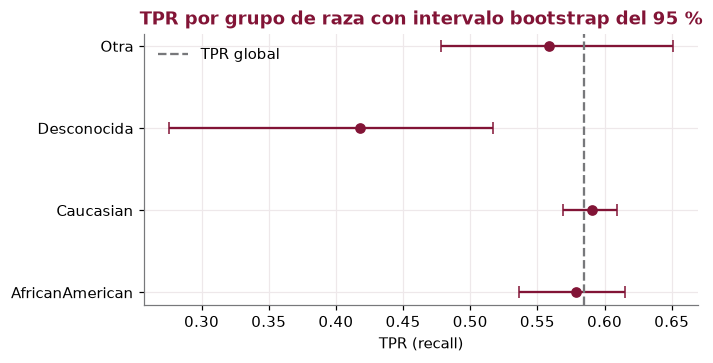

,TPR,IC 2.5 %,IC 97.5 %,positivos en prueba
raza,,,,
AfricanAmerican,0.579,0.536,0.615,662
Caucasian,0.591,0.569,0.609,2579
Desconocida,0.418,0.276,0.517,55
Otra,0.559,0.478,0.651,111


In [8]:
mf_ci = MetricFrame(metrics={"TPR": true_positive_rate}, y_true=y_te, y_pred=pred_te, sensitive_features=s_te["raza"],
                    n_boot=200, ci_quantiles=[0.025, 0.975], random_state=SEED)
ic = pd.DataFrame({"TPR": mf_ci.by_group["TPR"], "IC 2.5 %": mf_ci.by_group_ci[0]["TPR"], "IC 97.5 %": mf_ci.by_group_ci[1]["TPR"],
                   "positivos en prueba": y_te.groupby(s_te["raza"]).sum()}).round(3)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.errorbar(ic["TPR"], ic.index, xerr=[ic["TPR"] - ic["IC 2.5 %"], ic["IC 97.5 %"] - ic["TPR"]], fmt="o", color=UEES["vino"], capsize=4)
ax.axvline(true_positive_rate(y_te, pred_te), ls="--", color=UEES["gris"], label="TPR global")
ax.set(title="TPR por grupo de raza con intervalo bootstrap del 95 %", xlabel="TPR (recall)")
ax.legend()
plt.show()
ic

**Qué observar.** El modelo es débil (AUC ≈ 0.64: el reingreso depende de muchas cosas que no están en los datos) y selecciona al 40 % de los pacientes. Entre pacientes afroamericanos y caucásicos las tasas son casi iguales y sus intervalos se superponen. La mayor brecha está en el grupo **Desconocida**: TPR 0.42 frente a 0.59, con un intervalo que no se superpone con el de los caucásicos. Los pacientes cuyo registro está incompleto reciben menos el programa: un problema de **calidad de datos** se convierte en uno de **equidad**. Por edad, la tasa de selección va del 31 % (30–60 años) al 44 % (más de 60).

### 3.1 Mitigación y su costo

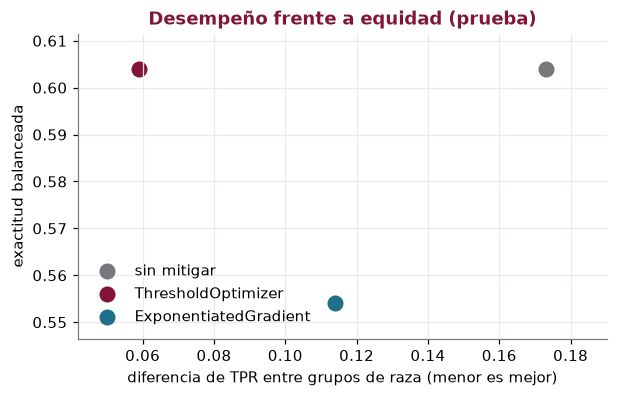

,exactitud balanceada,recall global,pacientes seleccionados,diferencia de TPR,diferencia de FPR
modelo,,,,,
sin mitigar,0.604,0.585,0.399,0.173,0.143
ThresholdOptimizer,0.604,0.665,0.480,0.059,0.058
ExponentiatedGradient,0.554,0.460,0.365,0.114,0.054


In [9]:
to_h = ThresholdOptimizer(estimator=modelo, constraints="true_positive_rate_parity", objective="balanced_accuracy_score",
                          prefit=True, predict_method="predict_proba").fit(X_tr, y_tr, sensitive_features=s_tr["raza"])
pred_to = to_h.predict(X_te, sensitive_features=s_te["raza"], random_state=SEED)

prep_fit = modelo[0]                                          # el mismo preprocesamiento, ajustado solo con el entrenamiento
Z_tr, Z_te = prep_fit.transform(X_tr), prep_fit.transform(X_te)
eg_h = ExponentiatedGradient(LogisticRegression(max_iter=2000, class_weight="balanced"),
                             constraints=TruePositiveRateParity(difference_bound=0.01), max_iter=50).fit(Z_tr, y_tr, sensitive_features=s_tr["raza"])
pred_eg = eg_h.predict(Z_te, random_state=SEED)

filas = []
for nombre, pred in (("sin mitigar", pred_te), ("ThresholdOptimizer", pred_to), ("ExponentiatedGradient", pred_eg)):
    mfr = MetricFrame(metrics={"TPR": true_positive_rate, "FPR": false_positive_rate, "selección": selection_rate},
                      y_true=y_te, y_pred=pred, sensitive_features=s_te["raza"])
    filas.append({"modelo": nombre, "exactitud balanceada": balanced_accuracy_score(y_te, pred), "recall global": true_positive_rate(y_te, pred),
                  "pacientes seleccionados": np.mean(pred), "diferencia de TPR": mfr.difference()["TPR"], "diferencia de FPR": mfr.difference()["FPR"]})
tabla_mit = pd.DataFrame(filas).set_index("modelo").round(3)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
for (nombre, fila), color in zip(tabla_mit.iterrows(), (UEES["gris"], UEES["vino"], UEES["azul"])):
    ax.scatter(fila["diferencia de TPR"], fila["exactitud balanceada"], s=90, color=color, label=nombre)
ax.set(title="Desempeño frente a equidad (prueba)", xlabel="diferencia de TPR entre grupos de raza (menor es mejor)", ylabel="exactitud balanceada")
ax.margins(0.15)
ax.legend()
plt.show()
tabla_mit

**Qué observar.** `ThresholdOptimizer` baja la diferencia de TPR de 0.17 a 0.06 sin perder exactitud balanceada, pero **sube la selección del 40 % al 48 %**: el hospital tendría que atender a ocho pacientes más de cada cien, y la FPR sube para todos. Además usa la raza al decidir, lo que debe discutirse con el área legal y con los pacientes. `ExponentiatedGradient` aquí **no** mejora: pierde exactitud y la diferencia en la prueba sigue alta, porque los grupos pequeños hacen que lo que se iguala en el entrenamiento no se sostenga. Ninguna mitigación arregla la causa (registros incompletos): esa se ataca en la recolección de datos.

## Nivel 4 · Informe de auditoría y registro de riesgos

El NIST AI RMF organiza la gestión de riesgos en cuatro funciones: **Gobernar** (políticas, roles, responsables), **Mapear** (contexto y riesgos), **Medir** (analizar y seguir los riesgos) y **Gestionar** (priorizar, responder, monitorear). Completa el registro con al menos cinco riesgos, cada uno con evidencia de esta auditoría.

In [10]:
registro = pd.DataFrame([
    {"riesgo": "El programa llega menos a pacientes con raza desconocida (registro incompleto)", "función NIST": "Medir",
     "evidencia": f"TPR {ic.loc['Desconocida', 'TPR']:.2f} frente a {ic.loc['Caucasian', 'TPR']:.2f} (caucásicos)", "probabilidad": "alta", "impacto": "alto",
     "mitigación": "Mejorar la captura de datos; umbral por grupo mientras tanto; revisión humana de casos con datos faltantes", "responsable": "Calidad de datos clínicos"},
    # TODO: agrega al menos cuatro riesgos más (por ejemplo: modelo débil, costo de la mitigación, uso de la raza al decidir,
    #       pacientes repetidos entre entrenamiento y prueba, deriva de los datos con el tiempo, falta de un responsable).
    {"riesgo": "Modelo débil: la mayoría de las selecciones son falsos positivos", "función NIST": "Medir",
     "evidencia": f"AUC {roc_auc_score(y_te, p_te):.2f}; precisión global {auditoria['raza'].overall['precisión']:.2f}", "probabilidad": "alta", "impacto": "medio",
     "mitigación": "Presentarlo como apoyo a la priorización, no como diagnóstico; buscar variables clínicas adicionales", "responsable": "Equipo de ciencia de datos"},
    {"riesgo": "La mitigación aumenta la carga del programa", "función NIST": "Gestionar",
     "evidencia": f"selección {tabla_mit.loc['sin mitigar', 'pacientes seleccionados']:.0%} → {tabla_mit.loc['ThresholdOptimizer', 'pacientes seleccionados']:.0%}", "probabilidad": "alta", "impacto": "medio",
     "mitigación": "Acordar la capacidad del programa y el umbral con la dirección clínica", "responsable": "Dirección médica"},
    {"riesgo": "Usar la raza para fijar umbrales puede no ser aceptable legal o socialmente", "función NIST": "Gobernar",
     "evidencia": "ThresholdOptimizer necesita el grupo al predecir", "probabilidad": "media", "impacto": "alto",
     "mitigación": "Consulta legal y ética; alternativa sin atributo sensible al predecir", "responsable": "Comité de ética"},
    {"riesgo": "Pacientes con varias hospitalizaciones pueden estar en entrenamiento y prueba", "función NIST": "Mapear",
     "evidencia": "Esta versión de los datos no trae identificador de paciente", "probabilidad": "media", "impacto": "medio",
     "mitigación": "Partir por paciente (GroupKFold) con los datos originales", "responsable": "Equipo de ciencia de datos"},
    {"riesgo": "Los datos son de 1999–2008: prácticas clínicas y población cambiaron", "función NIST": "Gestionar",
     "evidencia": "Periodo de recolección del conjunto", "probabilidad": "alta", "impacto": "medio",
     "mitigación": "Validar con datos recientes del hospital y monitorear deriva (E4.3)", "responsable": "Equipo de MLOps"},
])
display(registro)

,riesgo,función NIST,evidencia,probabilidad,impacto,mitigación,responsable
0,El programa llega menos a pacientes con raza d...,Medir,TPR 0.42 frente a 0.59 (caucásicos),alta,alto,Mejorar la captura de datos; umbral por grupo ...,Calidad de datos clínicos
1,Modelo débil: la mayoría de las selecciones so...,Medir,AUC 0.64; precisión global 0.16,alta,medio,"Presentarlo como apoyo a la priorización, no c...",Equipo de ciencia de datos
2,La mitigación aumenta la carga del programa,Gestionar,selección 40% → 48%,alta,medio,Acordar la capacidad del programa y el umbral ...,Dirección médica
3,Usar la raza para fijar umbrales puede no ser ...,Gobernar,ThresholdOptimizer necesita el grupo al predecir,media,alto,Consulta legal y ética; alternativa sin atribu...,Comité de ética
4,Pacientes con varias hospitalizaciones pueden ...,Mapear,Esta versión de los datos no trae identificado...,media,medio,Partir por paciente (GroupKFold) con los datos...,Equipo de ciencia de datos
5,Los datos son de 1999–2008: prácticas clínicas...,Gestionar,Periodo de recolección del conjunto,alta,medio,Validar con datos recientes del hospital y mon...,Equipo de MLOps


> **Respuesta de referencia**

**Informe de auditoría (resumen).** El modelo de reingreso (regresión logística, AUC 0.64) selecciona al 40 % de los pacientes para el programa. Por raza, las tasas de pacientes afroamericanos y caucásicos son equivalentes; la brecha principal es para los pacientes con **raza desconocida** (TPR 0.42 frente a 0.59), un síntoma de registros incompletos. Con `ThresholdOptimizer` la brecha de TPR baja a 0.06 sin perder exactitud balanceada, a cambio de un 8 % más de pacientes en el programa y de usar la raza al decidir. **Recomendación:** usar el modelo solo como apoyo a la priorización, con revisión humana; corregir la captura de datos y monitorear la TPR por grupo cada trimestre; decidir el uso de umbrales por grupo con el comité de ética.

## Autoverificación

In [11]:
assert np.allclose(mf.by_group[["selección", "TPR", "FPR", "precisión"]].to_numpy(float), tabla_comun.to_numpy(float))
assert abs(tabla_tpr.loc["A", "TPR"] - tabla_tpr.loc["B", "TPR"]) < 0.02, "Los umbrales por grupo deberían igualar la TPR."
assert abs(tabla_tpr.loc["A", "precisión"] - tabla_tpr.loc["B", "precisión"]) > 0.1, "Con TPR igual y tasas base distintas, la precisión debería separarse."
assert tabla_sint.loc["ThresholdOptimizer", "diferencia de TPR"] < tabla_sint.loc["sin mitigar", "diferencia de TPR"]
assert tabla_mit.loc["ThresholdOptimizer", "diferencia de TPR"] < tabla_mit.loc["sin mitigar", "diferencia de TPR"] / 2
assert len(registro) >= 5 and registro.notna().all().all(), "El registro necesita al menos cinco riesgos completos."
print("✓ E4.2 completo")

✓ E4.2 completo


## Lista de cotejo (autoevaluación del laboratorio)

- [ ] Calculaste selección, TPR, FPR y precisión por grupo desde la matriz de confusión.
- [ ] Explicaste por qué no se pueden igualar a la vez la precisión y las tasas de error.
- [ ] Auditaste el modelo por raza, género y edad con `MetricFrame` e intervalos de confianza.
- [ ] Comparaste dos mitigaciones con su costo en desempeño y en carga del programa.
- [ ] Escribiste el informe y un registro de riesgos con funciones del NIST AI RMF.

**Reflexión:** en tu organización, ¿qué error perjudica más a las personas afectadas por un modelo, el falso positivo o el falso negativo? ¿Qué métrica de equidad se sigue de esa respuesta?

**Cómo te prepara para el examen práctico:** el examen pide una auditoría de equidad con `MetricFrame` (sexo y raza en ACS Income), una mitigación si corresponde y un registro de riesgos alineado con el NIST AI RMF.

## Desafío opcional con IA agéntica · Otra métrica, otra mitigación

**Objetivo.** Auditar el mismo modelo por otro atributo y con otra restricción de equidad, y documentar el compromiso.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
En el notebook resuelto E4.2 (auditoría con Fairlearn sobre Diabetes 130-Hospitals), agrega una sección que audite por grupo de edad con MetricFrame, con tamaños e intervalos. Prueba ThresholdOptimizer con la restricción de odds igualadas y compara el desempeño, la brecha y la tasa de selección con el modelo sin mitigar. Escribe en español una recomendación breve que diga a quién perjudica cada error y cuánto cuesta la mitigación.
```

**Cómo verificar el resultado**

- Cada grupo se reporta con su tamaño y su intervalo.
- La mitigación se ajusta con el entrenamiento y se evalúa en la prueba.
- La recomendación menciona que ThresholdOptimizer usa el atributo sensible al decidir.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.